# E5063A — Instrument Sweep-Rate vs Configuration

**Dataset:** `REPORT/20260604/20260604/` — Device **Sanity Check** runs collected with the
E5063A Data Collector GUI on 2026-06-04 (Keysight E5063A, SN MY54806798, FW A.07.06, S11, −5 dBm,
30 sweeps per IFBW, host-paced continuous latched read).

## What was swept
| Dimension | Values |
|---|---|
| **Number of points** | 101, 201, 301, 401, 501, 601, 701, 801, 901, 1001 (200–250 MHz span) |
| **Start/stop frequency** | 200–250 MHz (50 MHz span) vs 230–250 MHz (20 MHz span), both at 801 pt |
| **IFBW** (inner sweep, every run) | 300, 150, 125, 100, 75, 50, 1 kHz (+10 kHz on the 230–250/801 run) |

For each run, the workbook stores per-IFBW **Mean Sweep (ms)**, **Update Rate (Hz)**, **Noise Floor (dB)**
and **Trace Jitter (dB)**.

## Objectives
1. Quantify sweep rate / mean sweep time vs **IFBW** and vs **number of points** (§1–§2).
2. Build a 2-D operating map and locate the (points, IFBW) region clearing the **20 / 25 / 30 Hz** biomedical targets (§3).
3. Fit an analytical sweep-time model `mean_ms ≈ overhead + N·(a + b/IFBW)` to predict untested configs (§4).
4. Confirm sweep rate is driven by **points × IFBW**, not absolute frequency / span (§5).
5. Characterise the **speed↔quality** tradeoff (noise floor, jitter) (§6).
6. Cross-check against the live **Monitor (Dataflux) CSV** achieved log rate (§7), and summarise a recommended operating point (§8).

In [ ]:
# --- Imports, dark style (matches notebook 1), constants ---------------------
import os, re, glob
from datetime import datetime

import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns                      # used only for the fig-3 heatmap
from scipy.optimize import curve_fit

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# Dark-background palette (matches 1_single_vs_continuous_sweep_e5063a.ipynb)
COLOR_GOLD  = "#FFD700"     # 200-250 MHz / single accent
COLOR_CYAN  = "#00E5FF"     # 230-250 MHz / secondary accent
COLOR_RED   = "#FF3333"     # 25 Hz target
COLOR_AMBER = "#FFA000"     # 20 Hz reference
COLOR_GREEN = "#00E676"     # 30 Hz target
TARGET_COLORS = {20: COLOR_AMBER, 25: COLOR_RED, 30: COLOR_GREEN}
CMAP = plt.cm.plasma        # perceptually-uniform series colourmap
LEG  = dict(facecolor='#1a1a1a', edgecolor='white', labelcolor='white')

def _dark_ax(ax):
    """Apply the notebook-1 dark axis treatment."""
    ax.set_facecolor('black')
    ax.tick_params(colors='white', labelsize=9)
    for s in ax.spines.values():
        s.set_color('white')
    ax.grid(True, color='white', linestyle='--', linewidth=0.4, alpha=0.25)
    ax.set_axisbelow(True)

def _white_legend_title(ax):
    lg = ax.get_legend()
    if lg is not None and lg.get_title() is not None:
        lg.get_title().set_color('white')

DATA_DIR = r'D:/AUNUUN JEFFRY MAHBUUBI/PROJECT AND RESEARCH/PROJECTS/54. LibreVNA Vector Network Analyzer/REPORT/20260604/20260604'
FIG_DIR  = os.path.join(os.getcwd(), 'figures_20260604_sweep_rate')
os.makedirs(FIG_DIR, exist_ok=True)

TARGETS = [20, 25, 30]          # Hz biomedical monitoring targets

def savefig(fig, name):
    p = os.path.join(FIG_DIR, name)
    fig.savefig(p, facecolor=fig.get_facecolor())
    print('saved', p)

print('data dir exists:', os.path.isdir(DATA_DIR))
print('figures ->', FIG_DIR)

data dir exists: True
figures -> D:\AUNUUN JEFFRY MAHBUUBI\PROJECT AND RESEARCH\PROJECTS\54. LibreVNA Vector Network Analyzer\CODE\VNA-Project\code\ena-dev\notebook\figures_20260604_sweep_rate


In [ ]:
# --- Parse the 11 Sanity Check workbooks into one tidy long DataFrame --------
def read_sanity(path):
    wb = openpyxl.load_workbook(path, read_only=True, data_only=True)
    ws = wb['Sanity Check']
    rows = list(ws.iter_rows(values_only=True))
    keys = ('Model','Serial','Start (MHz)','Stop (MHz)','Points','Power (dBm)','Sweeps / IFBW')
    cfg = {r[0]: r[1] for r in rows if r and r[0] in keys}
    hi = next(i for i, r in enumerate(rows) if r and r[0] == 'IFBW (kHz)')
    recs = []
    for r in rows[hi+1:]:
        if r is None or r[0] is None:
            continue
        recs.append(dict(
            file=os.path.basename(path),
            start_mhz=cfg['Start (MHz)'], stop_mhz=cfg['Stop (MHz)'],
            span_mhz=cfg['Stop (MHz)'] - cfg['Start (MHz)'], points=int(cfg['Points']),
            power_dbm=cfg['Power (dBm)'], num_sweeps=int(cfg['Sweeps / IFBW']),
            ifbw_khz=float(r[0]), mean_ms=float(r[1]), rate_hz=float(r[2]),
            nf_db=float(r[3]), jitter_db=float(r[4]),
        ))
    return recs

recs = []
for f in sorted(glob.glob(os.path.join(DATA_DIR, 'run_sanity_*.xlsx'))):
    recs += read_sanity(f)
df = pd.DataFrame(recs).sort_values(['span_mhz','points','ifbw_khz']).reset_index(drop=True)

# 'rate_check' = 1000/mean_ms — confirms stored Update Rate is just the reciprocal of mean sweep
df['rate_check_hz'] = 1000.0 / df['mean_ms']
print('tidy frame:', df.shape, '| configs:', df.file.nunique())
print('points levels :', sorted(df.points.unique()))
print('IFBW levels   :', sorted(df.ifbw_khz.unique()))
print('max |rate - 1000/mean| =', (df.rate_hz - df.rate_check_hz).abs().max(), 'Hz (sanity: stored rate == 1/mean)')
df.head()

tidy frame: (78, 13) | configs: 11
points levels : [np.int64(101), np.int64(201), np.int64(301), np.int64(401), np.int64(501), np.int64(601), np.int64(701), np.int64(801), np.int64(901), np.int64(1001)]
IFBW levels   : [np.float64(1.0), np.float64(10.0), np.float64(50.0), np.float64(75.0), np.float64(100.0), np.float64(125.0), np.float64(150.0), np.float64(300.0)]
max |rate - 1000/mean| = 0.007082315191908606 Hz (sanity: stored rate == 1/mean)


,file,start_mhz,stop_mhz,span_mhz,points,power_dbm,num_sweeps,ifbw_khz,mean_ms,rate_hz,nf_db,jitter_db,rate_check_hz
0,run_sanity_S11_230-250MHz_801pt_multiIFBW_2026...,230,250,20,801,-5,30,1.0,789.310,1.267,-11.272,0.0038,1.266929
1,run_sanity_S11_230-250MHz_801pt_multiIFBW_2026...,230,250,20,801,-5,30,10.0,96.448,10.368,-11.272,0.0067,10.368281
2,run_sanity_S11_230-250MHz_801pt_multiIFBW_2026...,230,250,20,801,-5,30,50.0,34.483,29.000,-11.275,0.0120,28.999797
3,run_sanity_S11_230-250MHz_801pt_multiIFBW_2026...,230,250,20,801,-5,30,75.0,30.724,32.548,-11.276,0.0143,32.547845
4,run_sanity_S11_230-250MHz_801pt_multiIFBW_2026...,230,250,20,801,-5,30,100.0,28.000,35.714,-11.279,0.0175,35.714286


In [ ]:
# --- Parse the 2 Dataflux Monitor CSVs (live min-S11 logging) ----------------
def read_monitor(path):
    lines = open(path).read().splitlines()
    hdr = next(i for i, l in enumerate(lines) if l.startswith('Time,'))
    meta = {}
    for line in lines[:hdr]:
        if ',' in line:
            k, _, v = line.partition(',')
            meta[k.strip()] = v.strip()
    data = [l.split(',') for l in lines[hdr+1:] if l.strip()]
    t = [datetime.strptime(d[0], '%H:%M:%S.%f') for d in data]
    dt_ms = np.array([(t[i]-t[i-1]).total_seconds()*1000.0 for i in range(1, len(t))])
    freq_hz = np.array([float(d[1]) for d in data])
    mag_db  = np.array([float(d[2]) for d in data])
    return meta, freq_hz, mag_db, dt_ms

monitors = {}
for f in sorted(glob.glob(os.path.join(DATA_DIR, 'bloodvessel_monitor_*.csv'))):
    meta, freq, mag, dt = read_monitor(f)
    span = f"{float(meta['Freq Start(MHz)']):.0f}-{float(meta['Freq Stop(MHz)']):.0f} MHz"
    monitors[span] = dict(meta=meta, freq=freq, mag=mag, dt=dt)
    print(f"{span:14s} N={meta['Number of Data']:>5} hdr_log_int={meta['Log Interval(ms)']} ms "
          f"IFBW={meta['IF Bandwidth(KHz)']} kHz pts={meta['Points']}")

200-250 MHz    N= 2274 hdr_log_int=26.4 ms IFBW=300.000 kHz pts=801
230-250 MHz    N= 2288 hdr_log_int=26.2 ms IFBW=300.000 kHz pts=801


## §1 — Sweep rate vs IFBW

All point counts at the 200–250 MHz span. IFBW on a log axis (1 → 300 kHz). Horizontal lines mark the
20 / 25 / 30 Hz biomedical targets. The 1 kHz IFBW point (~1.3 Hz) sits far below and is shown only on the
log inset; the main panel focuses on the usable ≥50 kHz region.

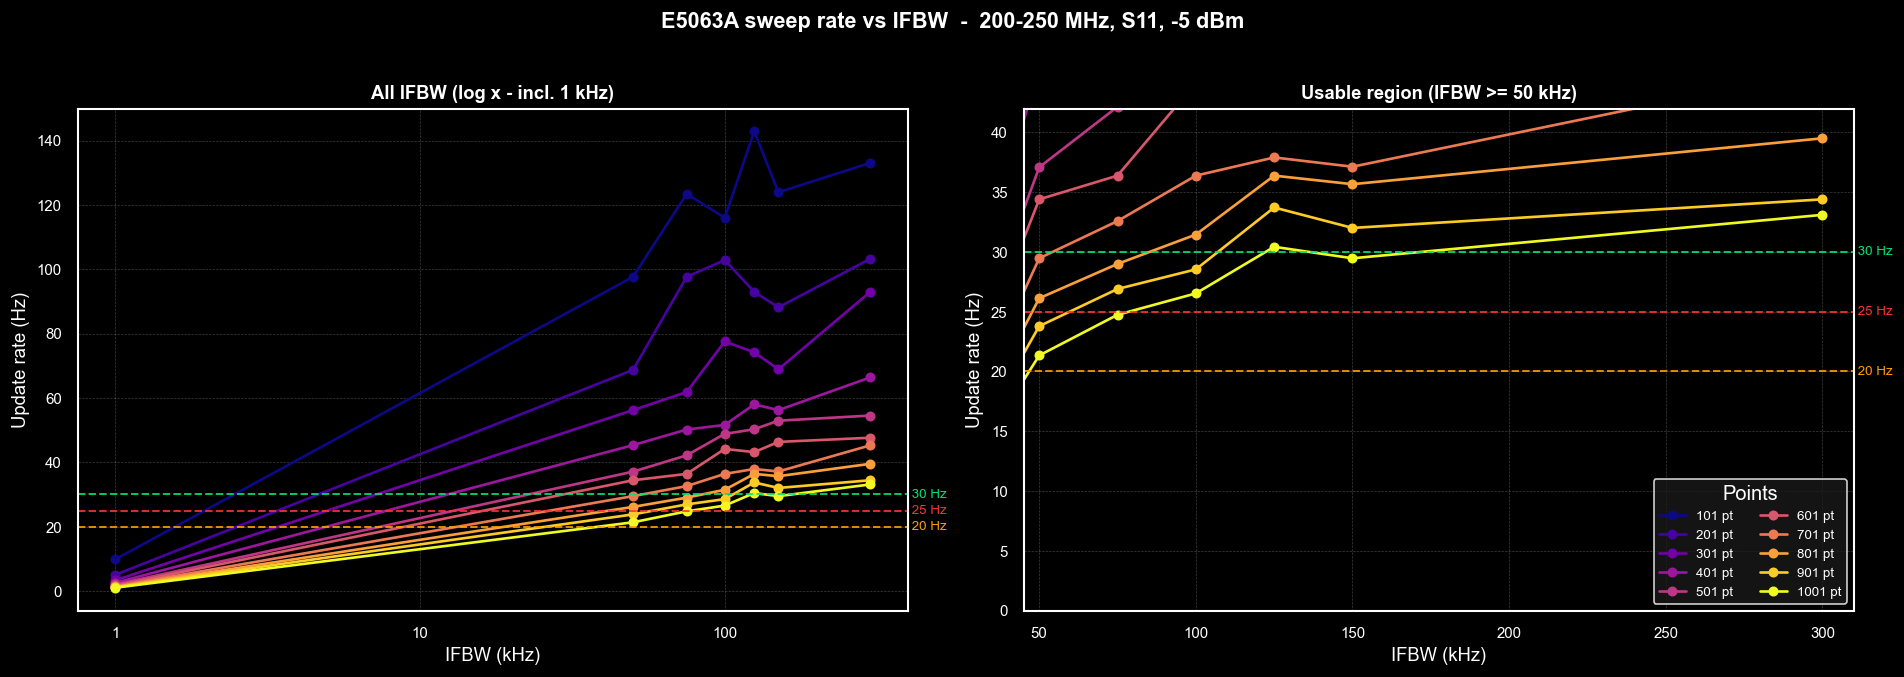

In [ ]:
# --- Fig 1: rate vs IFBW, one line per point count (dark style) -------------
plt.style.use('dark_background')
d50 = df[df.span_mhz == 50]
pts_levels = sorted(d50.points.unique())
colors = [CMAP(i / (len(pts_levels) - 1)) for i in range(len(pts_levels))]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor('black')
for c, N in zip(colors, pts_levels):
    g = d50[d50.points == N].sort_values('ifbw_khz')
    axA.plot(g.ifbw_khz, g.rate_hz, '-o', color=c, ms=5, lw=1.6, label=f'{N} pt')
    axB.plot(g.ifbw_khz, g.rate_hz, '-o', color=c, ms=5, lw=1.6, label=f'{N} pt')
for ax in (axA, axB):
    _dark_ax(ax)
    for t in TARGETS:
        ax.axhline(t, ls='--', lw=1.2, color=TARGET_COLORS[t], alpha=0.85)
    ax.set_xlabel('IFBW (kHz)', color='white', fontsize=11)
    ax.set_ylabel('Update rate (Hz)', color='white', fontsize=11)
axA.set_xscale('log'); axA.set_title('All IFBW (log x - incl. 1 kHz)', color='white', fontsize=11)
axA.xaxis.set_major_formatter(mticker.ScalarFormatter())
for t in TARGETS:
    axA.text(axA.get_xlim()[1], t, f' {t} Hz', va='center', ha='left', fontsize=8, color=TARGET_COLORS[t])
axB.set_xlim(45, 310); axB.set_ylim(0, 42)
axB.set_title('Usable region (IFBW >= 50 kHz)', color='white', fontsize=11)
for t in TARGETS:
    axB.text(axB.get_xlim()[1], t, f' {t} Hz', va='center', ha='left', fontsize=8, color=TARGET_COLORS[t])
axB.legend(title='Points', ncol=2, fontsize=8, loc='lower right', **LEG)
_white_legend_title(axB)
fig.suptitle('E5063A sweep rate vs IFBW  -  200-250 MHz, S11, -5 dBm',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig(fig, 'fig1_rate_vs_ifbw.png'); plt.show()

## §2 — Sweep rate & mean sweep time vs number of points

At fixed IFBW, rate falls and mean sweep time rises with point count. Mean sweep time is expected to be
**near-linear** in N (`overhead + N · per-point cost`); a per-IFBW linear fit extracts the fixed overhead
(intercept) and per-point slope.

saved D:\AUNUUN JEFFRY MAHBUUBI\PROJECT AND RESEARCH\PROJECTS\54. LibreVNA Vector Network Analyzer\CODE\VNA-Project\code\ena-dev\notebook\figures_20260604_sweep_rate\fig2_vs_points.png


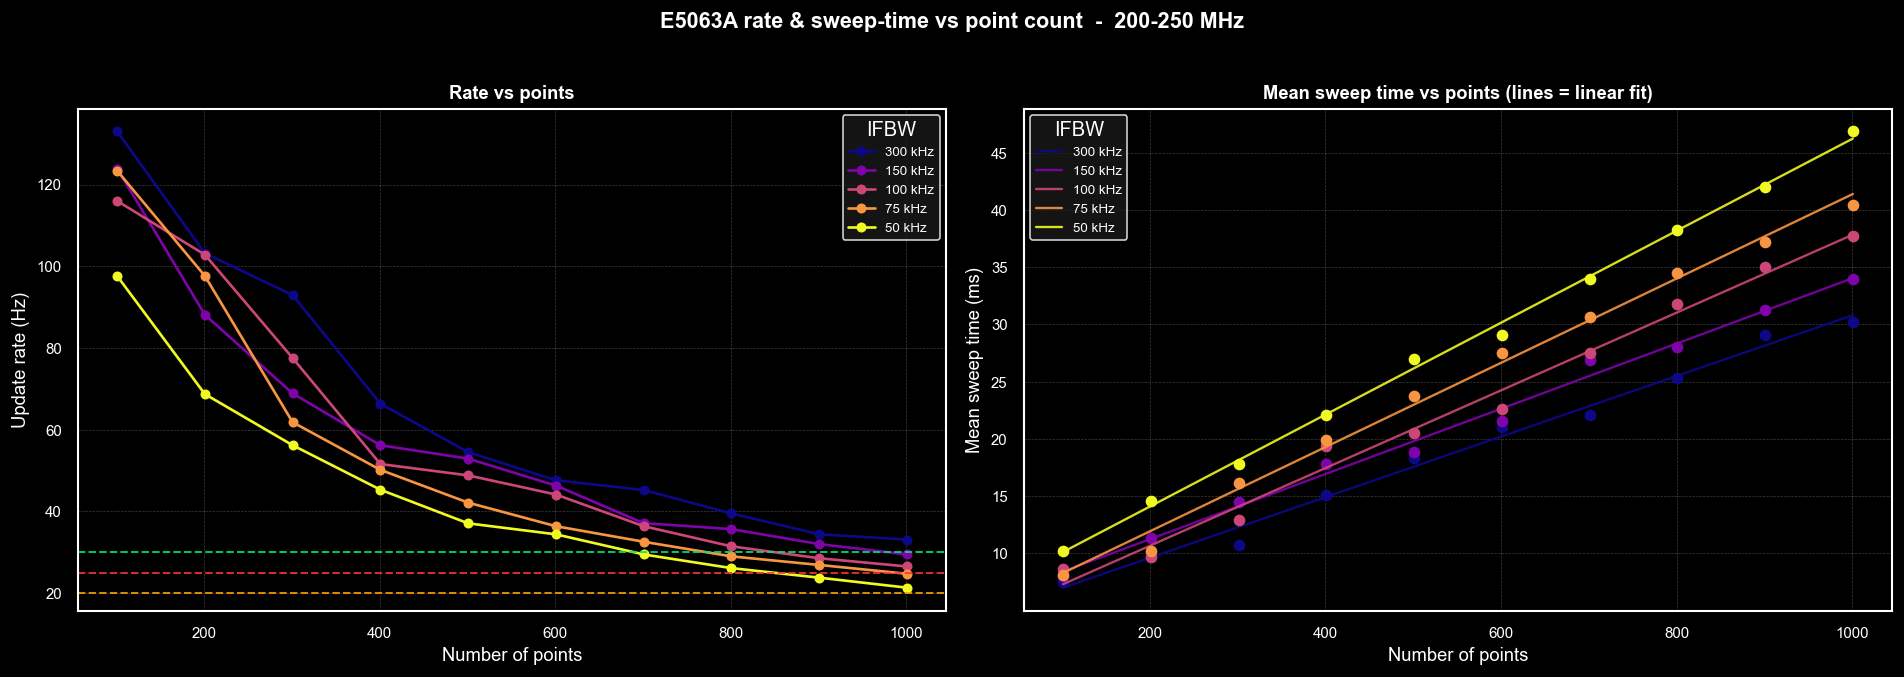

 ifbw_khz  overhead_ms  per_point_us
      300         4.33         26.45
      150         5.55         28.47
      100         3.88         33.92
       75         4.57         36.78
       50         6.07         40.13

per-IFBW linear fit: mean_ms = overhead + per_point*N  (overhead grows slightly as IFBW narrows)


In [ ]:
# --- Fig 2: rate vs points (left) + mean_ms vs points with fits (right) -----
plt.style.use('dark_background')
ifbw_show = [300, 150, 100, 75, 50]
colors = [CMAP(i / (len(ifbw_show) - 1)) for i in range(len(ifbw_show))]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor('black')
fit_tbl = []
for c, ib in zip(colors, ifbw_show):
    g = d50[d50.ifbw_khz == ib].sort_values('points')
    axL.plot(g.points, g.rate_hz, '-o', color=c, ms=5, lw=1.6, label=f'{ib} kHz')
    axR.plot(g.points, g.mean_ms, 'o', color=c, ms=6)
    m, b = np.polyfit(g.points, g.mean_ms, 1)
    xs = np.array([g.points.min(), g.points.max()])
    axR.plot(xs, m*xs + b, '-', color=c, lw=1.4, alpha=0.9, label=f'{ib} kHz')
    fit_tbl.append(dict(ifbw_khz=ib, overhead_ms=round(b, 2), per_point_us=round(m*1000, 2)))
for t in TARGETS:
    axL.axhline(t, ls='--', lw=1.2, color=TARGET_COLORS[t], alpha=0.85)
_dark_ax(axL); _dark_ax(axR)
axL.set_xlabel('Number of points', color='white', fontsize=11)
axL.set_ylabel('Update rate (Hz)', color='white', fontsize=11)
axL.set_title('Rate vs points', color='white', fontsize=11)
axL.legend(title='IFBW', fontsize=8, **LEG); _white_legend_title(axL)
axR.set_xlabel('Number of points', color='white', fontsize=11)
axR.set_ylabel('Mean sweep time (ms)', color='white', fontsize=11)
axR.set_title('Mean sweep time vs points (lines = linear fit)', color='white', fontsize=11)
axR.legend(title='IFBW', fontsize=8, **LEG); _white_legend_title(axR)
fig.suptitle('E5063A rate & sweep-time vs point count  -  200-250 MHz',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig(fig, 'fig2_vs_points.png'); plt.show()
print(pd.DataFrame(fit_tbl).to_string(index=False))
print('\nper-IFBW linear fit: mean_ms = overhead + per_point*N  (overhead grows slightly as IFBW narrows)')

## §3 — 2-D operating map (points × IFBW)

Heatmap of measured update rate over the full grid, with overlaid **iso-rate contours** at 20 / 25 / 30 Hz.
Everything above-left of a contour clears that target. This is the at-a-glance configuration selector.

saved D:\AUNUUN JEFFRY MAHBUUBI\PROJECT AND RESEARCH\PROJECTS\54. LibreVNA Vector Network Analyzer\CODE\VNA-Project\code\ena-dev\notebook\figures_20260604_sweep_rate\fig3_operating_map.png


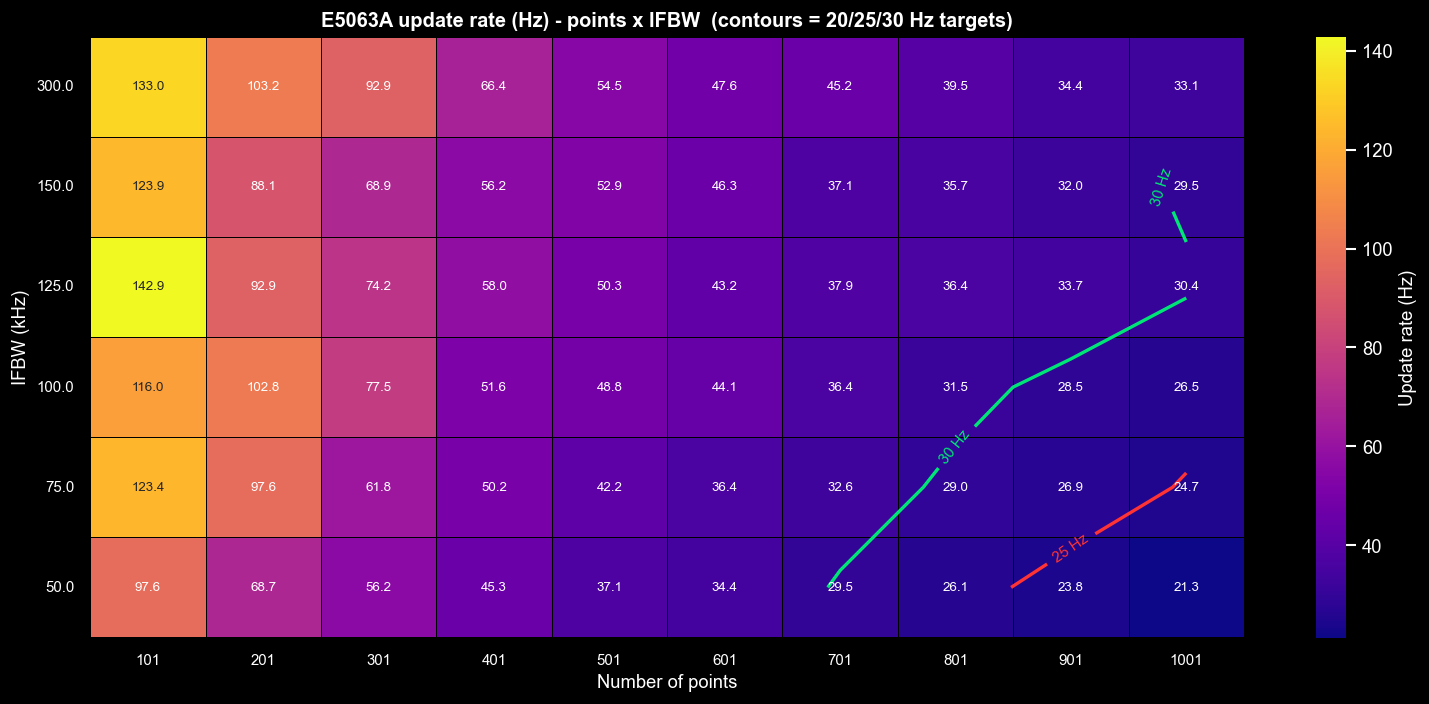

In [ ]:
# --- Fig 3: heatmap of rate over points x IFBW + iso-rate contours (dark) ---
plt.style.use('dark_background')
grid = (d50[d50.ifbw_khz >= 50]                      # drop the 1 kHz outlier for readability
        .pivot_table(index='ifbw_khz', columns='points', values='rate_hz'))
grid = grid.sort_index(ascending=False)             # high IFBW (fast) at top
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('black'); ax.set_facecolor('black')
hm = sns.heatmap(grid, annot=True, fmt='.1f', cmap='plasma',
                 cbar_kws={'label': 'Update rate (Hz)'},
                 linewidths=.5, linecolor='black', ax=ax, annot_kws={'fontsize': 8})
# iso-rate contours (target-line colours, matching the other figures)
X = np.arange(grid.shape[1]) + 0.5
Y = np.arange(grid.shape[0]) + 0.5
CS = ax.contour(X, Y, grid.values, levels=TARGETS,
                colors=[TARGET_COLORS[t] for t in TARGETS], linewidths=2)
ax.clabel(CS, fmt=lambda v: f'{v:.0f} Hz', fontsize=9)
ax.set_xlabel('Number of points', color='white', fontsize=11)
ax.set_ylabel('IFBW (kHz)', color='white', fontsize=11)
ax.set_title('E5063A update rate (Hz) - points x IFBW  (contours = 20/25/30 Hz targets)',
             color='white', fontsize=12, fontweight='bold')
ax.tick_params(colors='white', labelsize=9)
plt.setp(ax.get_yticklabels(), rotation=0)
# colourbar -> white labels/ticks/outline
cbar = hm.collections[0].colorbar
cbar.ax.yaxis.label.set_color('white'); cbar.ax.tick_params(colors='white')
cbar.outline.set_edgecolor('white')
plt.tight_layout()
savefig(fig, 'fig3_operating_map.png'); plt.show()

## §4 — Analytical sweep-time model

Physical decomposition of a VNA sweep: a fixed host/trigger **overhead**, a per-point fixed cost
(ADC/DSP), and a per-point IF-settling dwell that scales as **1/IFBW**:

$$ t_\text{sweep}(N, \text{IFBW}) \approx c_0 + N\cdot\left(a + \dfrac{b}{\text{IFBW}_\text{kHz}}\right) $$

Fit on the 200–250 MHz points sweep; then predicted rate `= 1000 / t_sweep`. A parity plot and residuals
validate the fit, and we compare the constants to the memory's fixed-801pt model `≈ 25 + 869/IFBW`.

MODEL  mean_ms = c0 + N*(a + b/IFBW_kHz)
  c0 (fixed overhead)      =   4.639 ms
  a  (per-point fixed cost)=  22.957 us/pt
  b  (per-point IF dwell)  =  0.9590 ms*kHz/pt
  R^2 = 0.99997   median |resid| = 0.70 ms
  -> at N=801: constant 23.0 ms + 768/IFBW   (memory model: 25 + 869/IFBW)


saved D:\AUNUUN JEFFRY MAHBUUBI\PROJECT AND RESEARCH\PROJECTS\54. LibreVNA Vector Network Analyzer\CODE\VNA-Project\code\ena-dev\notebook\figures_20260604_sweep_rate\fig4_model_fit.png


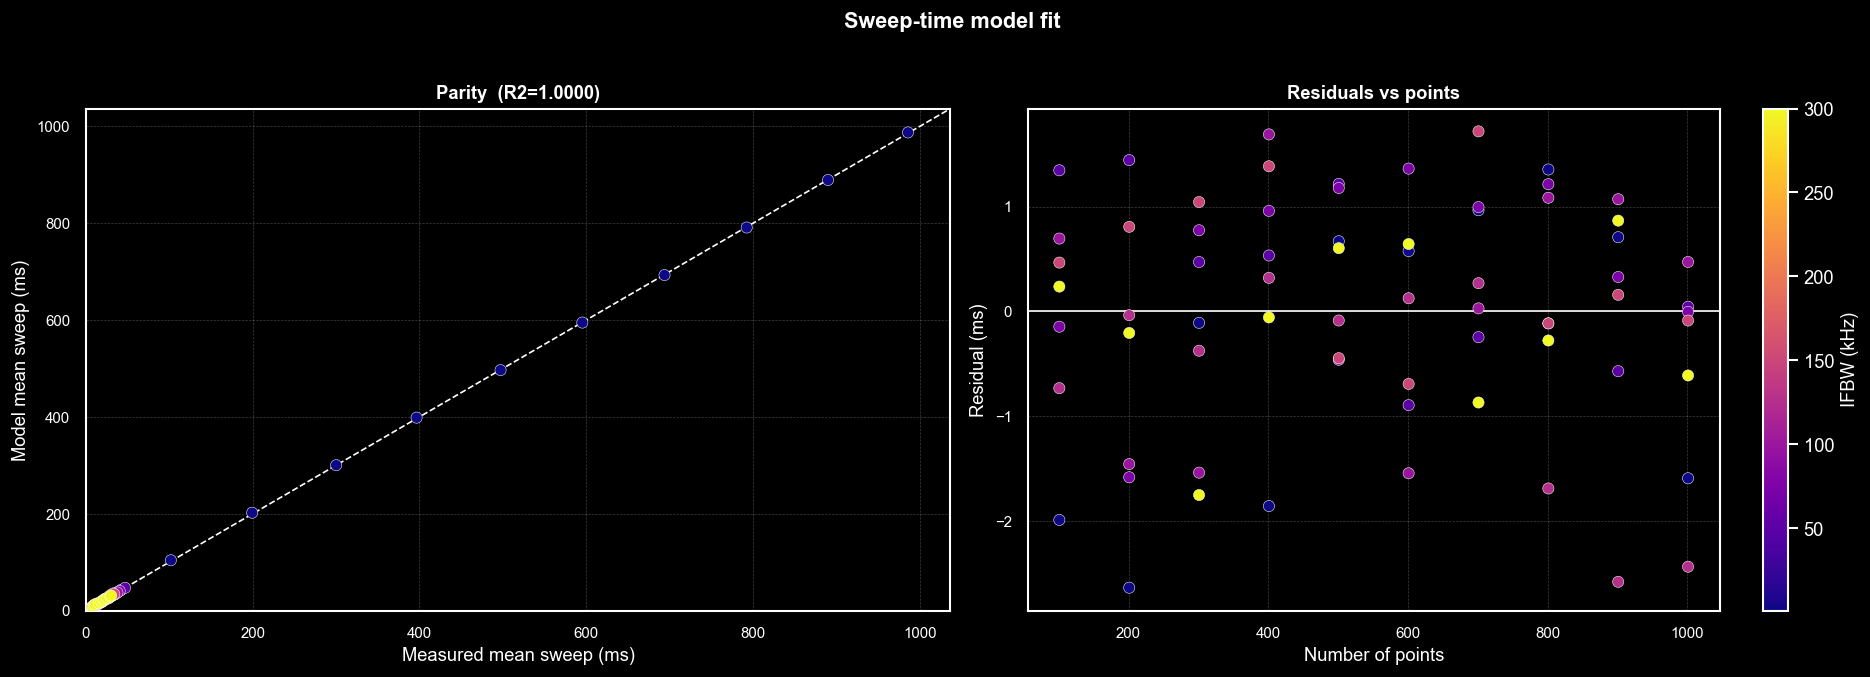


Predicted rate (Hz):
  201pt/300kHz=101.1  201pt/100kHz=89.4  201pt/50kHz=76.3
  401pt/300kHz=66.1  401pt/100kHz=56.5  401pt/50kHz=46.4
  801pt/300kHz=39.1  801pt/100kHz=32.6  801pt/50kHz=26.0


In [ ]:
# --- Fig 4: fit the sweep-time model + parity / residual plots (dark) -------
plt.style.use('dark_background')
fitdf = d50.copy()
def model(X, c0, a, b):
    N, ifbw = X
    return c0 + N * (a + b / ifbw)
X = (fitdf.points.values.astype(float), fitdf.ifbw_khz.values.astype(float))
y = fitdf.mean_ms.values.astype(float)
popt, _ = curve_fit(model, X, y, p0=[5, 0.02, 1.0], maxfev=20000)
c0, a, b = popt
yhat = model(X, *popt)
ss_res = np.sum((y-yhat)**2); ss_tot = np.sum((y-y.mean())**2); r2 = 1 - ss_res/ss_tot
print('MODEL  mean_ms = c0 + N*(a + b/IFBW_kHz)')
print(f'  c0 (fixed overhead)      = {c0:7.3f} ms')
print(f'  a  (per-point fixed cost)= {a*1000:7.3f} us/pt')
print(f'  b  (per-point IF dwell)  = {b:7.4f} ms*kHz/pt')
print(f'  R^2 = {r2:.5f}   median |resid| = {np.median(np.abs(y-yhat)):.2f} ms')
print(f'  -> at N=801: constant {c0 + 801*a:.1f} ms + {801*b:.0f}/IFBW   (memory model: 25 + 869/IFBW)')

fig, (axP, axR) = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor('black')
axP.scatter(y, yhat, c=fitdf.ifbw_khz, cmap='plasma', s=45, edgecolor='white', lw=.3, zorder=3)
lim = [0, max(y.max(), yhat.max())*1.05]
axP.plot(lim, lim, '--', color='white', lw=1)
_dark_ax(axP); axP.set_xlim(lim); axP.set_ylim(lim)
axP.set_xlabel('Measured mean sweep (ms)', color='white', fontsize=11)
axP.set_ylabel('Model mean sweep (ms)', color='white', fontsize=11)
axP.set_title(f'Parity  (R2={r2:.4f})', color='white', fontsize=11)
sc = axR.scatter(fitdf.points, y-yhat, c=fitdf.ifbw_khz, cmap='plasma', s=45, edgecolor='white', lw=.3, zorder=3)
axR.axhline(0, color='white', lw=1)
_dark_ax(axR)
axR.set_xlabel('Number of points', color='white', fontsize=11)
axR.set_ylabel('Residual (ms)', color='white', fontsize=11)
axR.set_title('Residuals vs points', color='white', fontsize=11)
cb = fig.colorbar(sc, ax=axR, label='IFBW (kHz)')
cb.ax.yaxis.label.set_color('white'); cb.ax.tick_params(colors='white')
cb.outline.set_edgecolor('white')
fig.suptitle('Sweep-time model fit', color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig(fig, 'fig4_model_fit.png'); plt.show()

def pred_rate(N, ib): return 1000.0 / model((N, ib), *popt)
print('\nPredicted rate (Hz):')
for N in [201, 401, 801]:
    print('  ' + '  '.join(f'{N}pt/{ib}kHz={pred_rate(N,ib):4.1f}' for ib in [300,100,50]))

## §5 — Frequency-span effect (200–250 vs 230–250 MHz)

Both runs are 801 pt. To first order, sweep timing is set by **points × IFBW**, not the absolute frequency
or span — the rate varies ~30× across IFBW but the two spans differ only modestly. This compares them across
shared IFBWs. *Caveat:* the two spans are separate acquisitions, so host-VISA scheduler jitter (±~10%, cf. the
fig-4 residuals) overlaps any true span effect.

saved D:\AUNUUN JEFFRY MAHBUUBI\PROJECT AND RESEARCH\PROJECTS\54. LibreVNA Vector Network Analyzer\CODE\VNA-Project\code\ena-dev\notebook\figures_20260604_sweep_rate\fig5_span_control.png


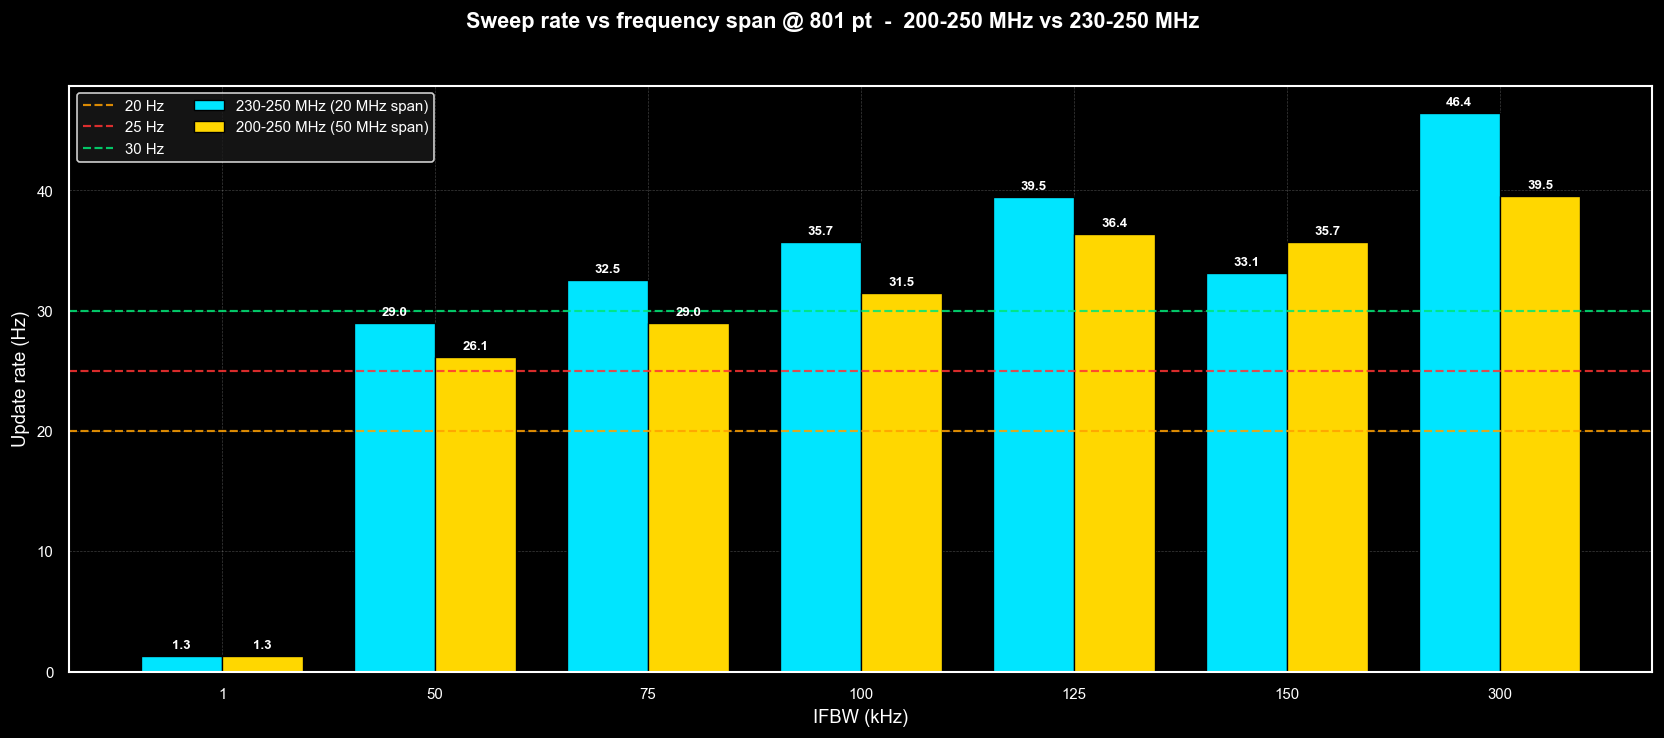

          20 MHz span  50 MHz span  delta_%
ifbw_khz                                   
1.0              1.27         1.26    -0.39
50.0            29.00        26.13    -9.91
75.0            32.55        29.00   -10.90
100.0           35.71        31.45   -11.93
125.0           39.46        36.39    -7.78
150.0           33.14        35.67     7.62
300.0           46.40        39.51   -14.85

mean |delta| = 9.1%, mean signed delta = -6.9% (20 MHz vs 50 MHz span).
First-order rate is set by points x IFBW (which varies ~30x here), NOT absolute frequency.
Secondary trend: the narrower 20 MHz span runs slightly FASTER at most IFBW (plausibly less
LO retune per frequency step); the 150 kHz point bucks the trend and is likely a single-run
jitter outlier. A clean span study would need repeated interleaved runs to separate the ~10%
span effect from the comparable ~10% host-VISA jitter.


In [ ]:
# --- Fig 5: span comparison at 801 pt (dark, grouped bars) ------------------
plt.style.use('dark_background')
a801 = df[(df.points == 801)].copy()
piv = a801.pivot_table(index='ifbw_khz', columns='span_mhz', values='rate_hz').dropna()
piv.columns = [f'{int(c)} MHz span' for c in piv.columns]   # ['20 MHz span', '50 MHz span']
piv['delta_%'] = (piv.iloc[:,1] - piv.iloc[:,0]) / piv.iloc[:,0] * 100

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('black')
shared = sorted(piv.index)
x = np.arange(len(shared)); w = 0.38
bars0 = ax.bar(x-w/2, piv.iloc[:,0].values, w, color=COLOR_CYAN, edgecolor='black',
               linewidth=0.8, label='230-250 MHz (20 MHz span)')
bars1 = ax.bar(x+w/2, piv.iloc[:,1].values, w, color=COLOR_GOLD, edgecolor='black',
               linewidth=0.8, label='200-250 MHz (50 MHz span)')
for bars in (bars0, bars1):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.4, f'{h:.1f}', ha='center', va='bottom',
                color='white', fontsize=8, fontweight='bold')
for t in TARGETS:
    ax.axhline(t, ls='--', lw=1.3, color=TARGET_COLORS[t], alpha=0.85, label=f'{t} Hz', zorder=2)
_dark_ax(ax)
ax.set_xticks(x); ax.set_xticklabels([f'{int(v)}' for v in shared])
ax.set_xlabel('IFBW (kHz)', color='white', fontsize=11)
ax.set_ylabel('Update rate (Hz)', color='white', fontsize=11)
ax.legend(fontsize=9, ncol=2, **LEG)
fig.suptitle('Sweep rate vs frequency span @ 801 pt  -  200-250 MHz vs 230-250 MHz',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig(fig, 'fig5_span_control.png'); plt.show()
print(piv.round(2).to_string())
md_abs = piv['delta_%'].abs().mean()
md_signed = piv['delta_%'].mean()
print(f'\nmean |delta| = {md_abs:.1f}%, mean signed delta = {md_signed:+.1f}% (20 MHz vs 50 MHz span).')
print('First-order rate is set by points x IFBW (which varies ~30x here), NOT absolute frequency.')
print('Secondary trend: the narrower 20 MHz span runs slightly FASTER at most IFBW (plausibly less')
print('LO retune per frequency step); the 150 kHz point bucks the trend and is likely a single-run')
print('jitter outlier. A clean span study would need repeated interleaved runs to separate the ~10%')
print('span effect from the comparable ~10% host-VISA jitter.')

## §6 — Speed ↔ quality tradeoff

Faster IFBW widens the IF filter → higher noise floor and trace jitter. These panels position the
recommended operating point: the slowest acceptable rate that buys the most dynamic range / lowest jitter.

saved D:\AUNUUN JEFFRY MAHBUUBI\PROJECT AND RESEARCH\PROJECTS\54. LibreVNA Vector Network Analyzer\CODE\VNA-Project\code\ena-dev\notebook\figures_20260604_sweep_rate\fig6_quality.png


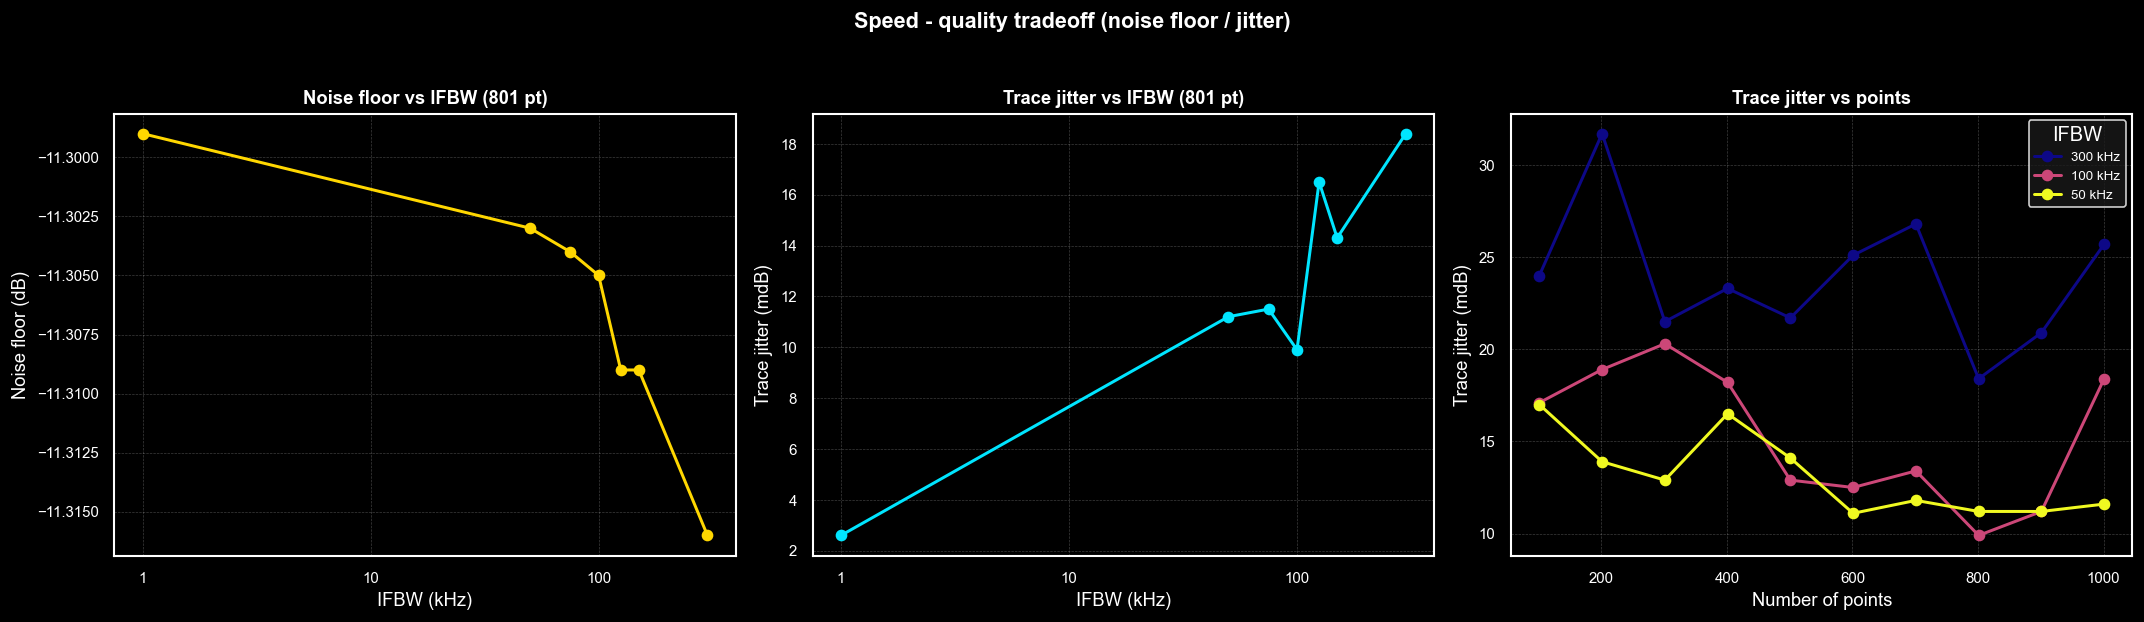

Noise floor varies only ~0.017 dB across all IFBW at 801 pt (essentially flat for S11 match work).


In [ ]:
# --- Fig 6: noise floor & jitter vs IFBW (and vs points) (dark) -------------
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('black')
# NF & jitter vs IFBW at 801 pt
g = d50[d50.points == 801].sort_values('ifbw_khz')
axes[0].plot(g.ifbw_khz, g.nf_db, '-o', color=COLOR_GOLD, lw=1.8, ms=6)
axes[0].set_xscale('log'); axes[0].xaxis.set_major_formatter(mticker.ScalarFormatter())
axes[0].set_xlabel('IFBW (kHz)', color='white', fontsize=11)
axes[0].set_ylabel('Noise floor (dB)', color='white', fontsize=11)
axes[0].set_title('Noise floor vs IFBW (801 pt)', color='white', fontsize=11)
axes[1].plot(g.ifbw_khz, g.jitter_db*1000, '-o', color=COLOR_CYAN, lw=1.8, ms=6)
axes[1].set_xscale('log'); axes[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
axes[1].set_xlabel('IFBW (kHz)', color='white', fontsize=11)
axes[1].set_ylabel('Trace jitter (mdB)', color='white', fontsize=11)
axes[1].set_title('Trace jitter vs IFBW (801 pt)', color='white', fontsize=11)
ifbw_q = [300, 100, 50]
qcolors = [CMAP(i / (len(ifbw_q) - 1)) for i in range(len(ifbw_q))]
for c, ib in zip(qcolors, ifbw_q):
    gg = d50[d50.ifbw_khz == ib].sort_values('points')
    axes[2].plot(gg.points, gg.jitter_db*1000, '-o', color=c, lw=1.8, ms=6, label=f'{ib} kHz')
axes[2].set_xlabel('Number of points', color='white', fontsize=11)
axes[2].set_ylabel('Trace jitter (mdB)', color='white', fontsize=11)
axes[2].set_title('Trace jitter vs points', color='white', fontsize=11)
axes[2].legend(title='IFBW', fontsize=8, **LEG); _white_legend_title(axes[2])
for ax in axes:
    _dark_ax(ax)
fig.suptitle('Speed - quality tradeoff (noise floor / jitter)',
             color='white', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
savefig(fig, 'fig6_quality.png'); plt.show()
print('Noise floor varies only ~%.3f dB across all IFBW at 801 pt (essentially flat for S11 match work).'
      % (g.nf_db.max() - g.nf_db.min()))

## §7 — Monitor (Dataflux) cross-check

The two live `bloodvessel_monitor` CSVs were logged at 801 pt / 300 kHz. The achieved per-sample interval
(from timestamps) should track the matching Sanity-Check sweep time. Note the CSV timestamps are quantised
(~15/16 ms host clock granularity) so the **mean** Δt — not the median — is the true rate, and matches the
header `Log Interval(ms)`.

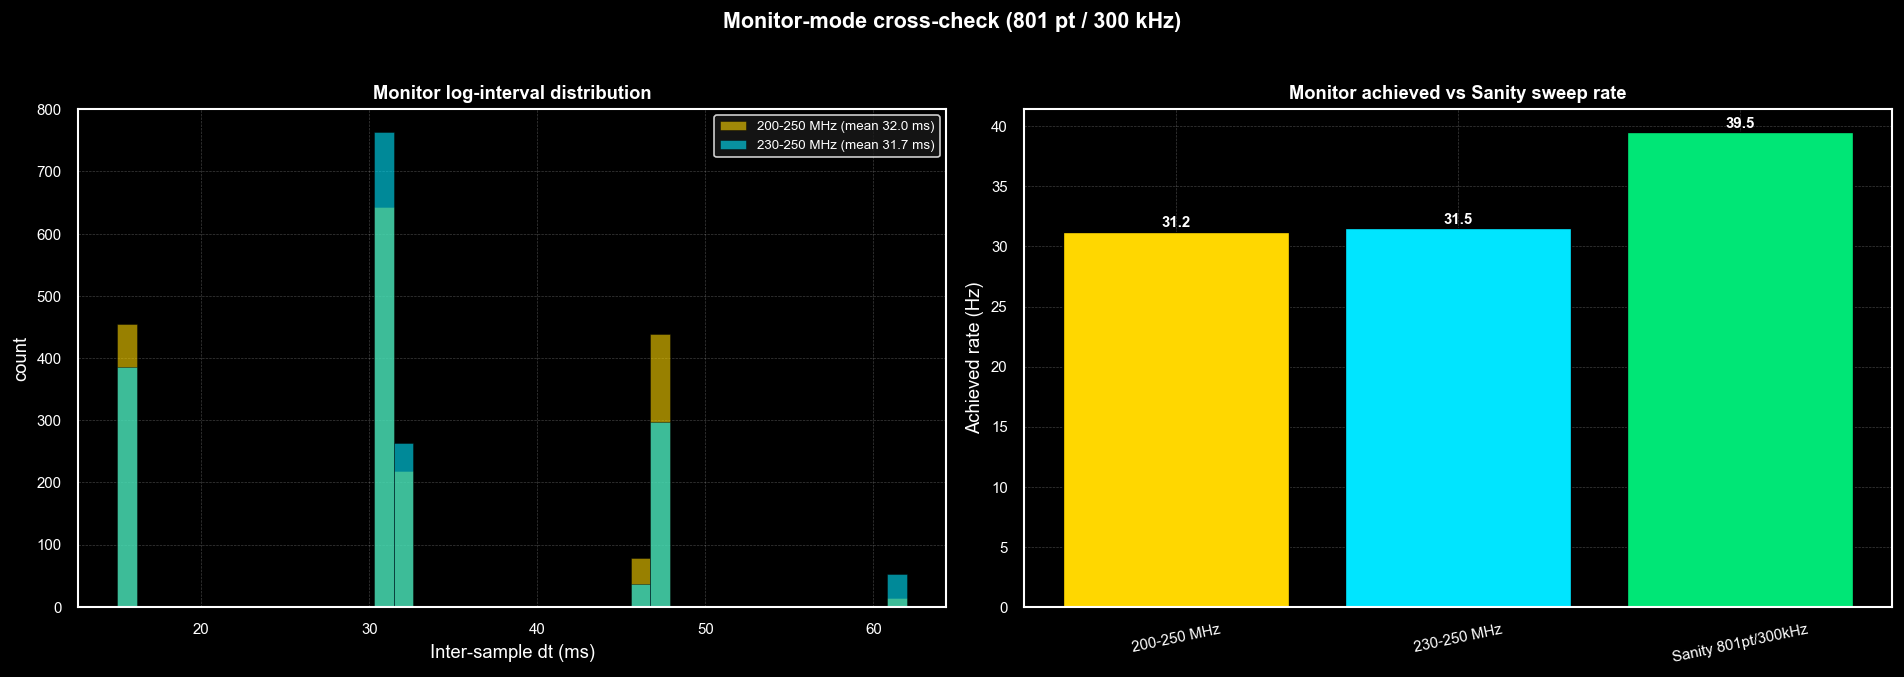

       span    n  mean_dt_ms  achieved_hz  hdr_log_int_ms
200-250 MHz 2274       32.01        31.24            26.4
230-250 MHz 2288       31.71        31.54            26.2

Sanity 801pt/300kHz: 39.51 Hz (25.31 ms).
Monitor achieved rate is slightly below the bare sweep rate — the gap is the per-sample marker-search + CSV-logging overhead added on top of each sweep.


In [ ]:
# --- Fig 7: monitor dt distribution + achieved rate vs sanity (dark) --------
plt.style.use('dark_background')
san_ref = d50[(d50.points==801) & (d50.ifbw_khz==300)].iloc[0]
fig, (axH, axS) = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor('black')
summary = []
hist_colors = [COLOR_GOLD, COLOR_CYAN]
for (span, m), hc in zip(monitors.items(), hist_colors):
    dt = m['dt']; dtc = dt[(dt>0) & (dt < np.percentile(dt, 99.5))]
    mean_dt = dtc.mean()
    axH.hist(dtc, bins=40, alpha=0.6, color=hc, edgecolor='black', linewidth=0.4,
             label=f'{span} (mean {mean_dt:.1f} ms)')
    summary.append(dict(span=span, n=len(dt)+1, mean_dt_ms=round(mean_dt,2),
                        achieved_hz=round(1000/mean_dt,2),
                        hdr_log_int_ms=float(m['meta']['Log Interval(ms)'])))
_dark_ax(axH)
axH.set_xlabel('Inter-sample dt (ms)', color='white', fontsize=11)
axH.set_ylabel('count', color='white', fontsize=11)
axH.set_title('Monitor log-interval distribution', color='white', fontsize=11)
axH.legend(fontsize=8, **LEG)
sumdf = pd.DataFrame(summary)
labels = list(sumdf.span) + ['Sanity 801pt/300kHz']
vals = list(sumdf.achieved_hz) + [san_ref.rate_hz]
bar_colors = [COLOR_GOLD, COLOR_CYAN, COLOR_GREEN]
bars = axS.bar(labels, vals, color=bar_colors[:len(labels)], edgecolor='black', linewidth=0.8)
for bar, v in zip(bars, vals):
    axS.text(bar.get_x()+bar.get_width()/2, v+0.4, f'{v:.1f}', ha='center',
             color='white', fontsize=9, fontweight='bold')
_dark_ax(axS)
axS.set_ylabel('Achieved rate (Hz)', color='white', fontsize=11)
axS.set_title('Monitor achieved vs Sanity sweep rate', color='white', fontsize=11)
axS.tick_params(axis='x', rotation=12)
fig.suptitle('Monitor-mode cross-check (801 pt / 300 kHz)',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig(fig, 'fig7_monitor.png'); plt.show()
print(sumdf.to_string(index=False))
print(f'\nSanity 801pt/300kHz: {san_ref.rate_hz:.2f} Hz ({san_ref.mean_ms:.2f} ms).')
print('Monitor achieved rate is slightly below the bare sweep rate — the gap is the per-sample marker-search + CSV-logging overhead added on top of each sweep.')

## §8 — Summary & recommended operating point

For each target rate, the table below lists the **largest point count** that still clears the target at a
given IFBW (more points = finer frequency resolution of the resonant notch). The recommendation balances
rate margin, point count, and dynamic range.

In [ ]:
# --- Qualifying configs per target + recommendation -------------------------
rows = []
for t in TARGETS:
    for ib in [300, 150, 125, 100, 75, 50]:
        ok = d50[(d50.ifbw_khz==ib) & (d50.rate_hz >= t)]
        maxN = int(ok.points.max()) if len(ok) else None
        rows.append(dict(target_hz=t, ifbw_khz=ib, max_points_clearing=maxN))
qual = pd.DataFrame(rows).pivot(index='ifbw_khz', columns='target_hz', values='max_points_clearing')
qual.columns = [f'≥{c} Hz: max pts' for c in qual.columns]
print('Largest point count clearing each target rate (200-250 MHz):')
print(qual.sort_index(ascending=False).to_string())

print('\n--- Recommendation -------------------------------------------------')
rec = d50[(d50.points==801) & (d50.ifbw_khz==300)].iloc[0]
print(f'801 pt / 300 kHz IFBW : {rec.rate_hz:.1f} Hz, NF {rec.nf_db:.1f} dB — clears 30 Hz with the finest grid tested.')
alt = d50[(d50.points==801) & (d50.ifbw_khz==50)].iloc[0]
print(f'801 pt /  50 kHz IFBW : {alt.rate_hz:.1f} Hz, NF {alt.nf_db:.1f} dB — clears 25 Hz with extra dynamic-range margin.')
print('\nDataset, parsing, model and figures validated against', df.file.nunique(), 'sanity runs +', len(monitors), 'monitor CSVs.')

Largest point count clearing each target rate (200-250 MHz):
          ≥20 Hz: max pts  ≥25 Hz: max pts  ≥30 Hz: max pts
ifbw_khz                                                   
300                  1001             1001             1001
150                  1001             1001              901
125                  1001             1001             1001
100                  1001             1001              801
75                   1001              901              701
50                   1001              801              601

--- Recommendation -------------------------------------------------
801 pt / 300 kHz IFBW : 39.5 Hz, NF -11.3 dB — clears 30 Hz with the finest grid tested.
801 pt /  50 kHz IFBW : 26.1 Hz, NF -11.3 dB — clears 25 Hz with extra dynamic-range margin.

Dataset, parsing, model and figures validated against 11 sanity runs + 2 monitor CSVs.
